# Newton Cannon Ball


In [ ]:
from vpython import *
scene = canvas()

scene.autoscale = False

rE = 6.371e6  #m's
rB = 2e5  
altitude = 1e6 #how high ball is off earth
deltaX = rE + altitude
scene.range = 1.5 * deltaX

Earth = sphere(pos=vec(0, 0, 0), radius=rE, color=color.blue) 
Ball = sphere(pos=vec(0, deltaX, 0), radius=rB, color=color.orange, make_trail=True) # Ball for Newtons Cannon
velocity = vec(7354, 0, 0) #changes initial velocity

G = 6.674e-11 #gravitational constant
m1 = 5.97217e24 #mass of earth
m2 = 600000 #Mass of ball (close to mass of a typical rocket)
dt = 100
t = 0

# verification
import math
r = rE + altitude
v_orbit = math.sqrt(G * m1 / r)
v_escape = math.sqrt(2 * G * m1 / r)
print(f"Expected orbital velocity: {v_orbit:.2f} m/s")
print(f"Expected escape velocity:  {v_escape:.2f} m/s")
print(f"Initial velocity:     {mag(velocity):.2f} m/s")


while mag(Ball.pos - Earth.pos) > rE:
    rate(1)  

    d_vector = Ball.pos - Earth.pos #vector distance
    d_scalar = mag(d_vector) #scalar distance
    d_direction = d_vector / d_scalar #distance direction

    F_scalar = (G*m1*m2)/d_scalar**2
    F = -F_scalar*d_direction

    a = F/m2
    

    
    velocity = velocity + a * dt  
    Ball.pos = Ball.pos + velocity * dt
    t = t + dt

    # print every 10 steps so it doesn't spam
    if int(t / dt) % 10 == 0:
        speed = mag(velocity)
        dist = d_scalar - rE  # altitude above surface
        print(f"t={t:.0f}s | speed={speed:.2f} m/s")
        





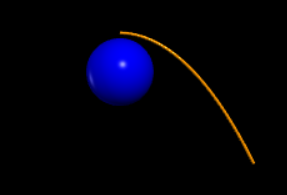
Image of ball 70 steps with initial velocity at 10400 m/s 

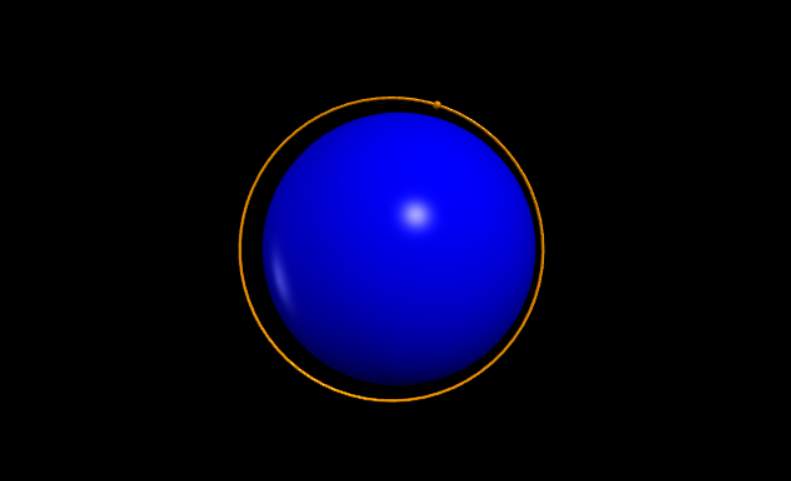
Image of ball 70 steps with initial velocity at 7354 m/s

Assumptions:
meters are used, all constant values are assumed using the NASA JPL Horizons System all be it slightly altered for units sake. Ball calculations for mass based off average rocket, and radius is assumed 200000 m. Time is meauresd in 100 x speed. Altitude that cannon shot is 100000 m.

To verify simulations, when program run it will say actual velocities for Escape: 10399.41 m/s, and Orbit: 7353.53 m/s. You can confirm that these values are true as the images shown in the markdown shows where the ball ends up after 70 time steps.

sources: 
https://ssd.jpl.nasa.gov/planets/phys_par.html

# The Solar System (Me-Ma)

C:\Users\there\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Expected orbital velocities (NASA / theoretical):
  Mercury: 47877.75 m/s  (NASA: 47,872 m/s)
  Venus:   35026.51 m/s  (NASA: 35,021 m/s)
  Earth:   29788.23 m/s  (NASA: 29,783 m/s)
  Mars:    24134.50 m/s  (NASA: 24,131 m/s)

Simulation complete: 1 Mercury year (88 days)

Final simulated vs expected velocities:
  Mercury: 47878.17 vs 47877.75 m/s  | error: 0.0009%
  Venus:   35044.26 vs 35026.51 m/s  | error: 0.0507%
  Earth:   29803.03 vs 29788.23 m/s  | error: 0.0497%
  Mars:    24139.11 vs 24134.50 m/s  | error: 0.0191%


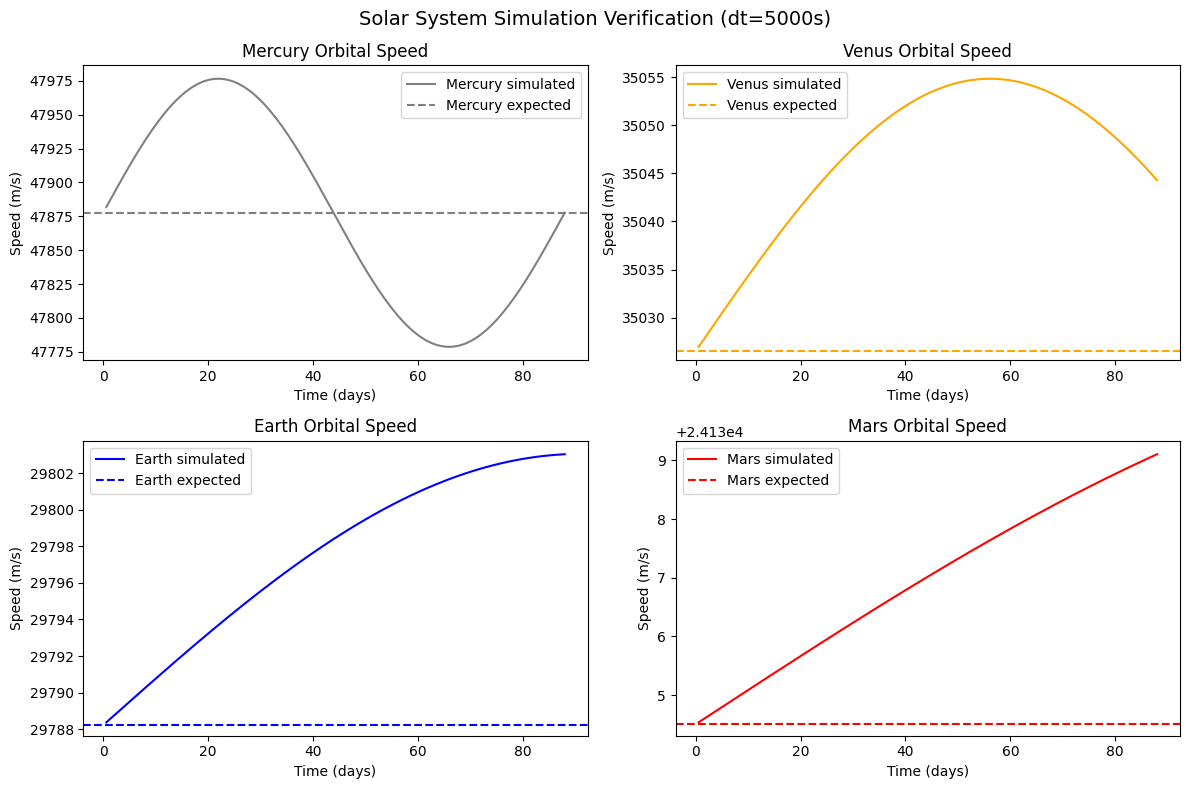

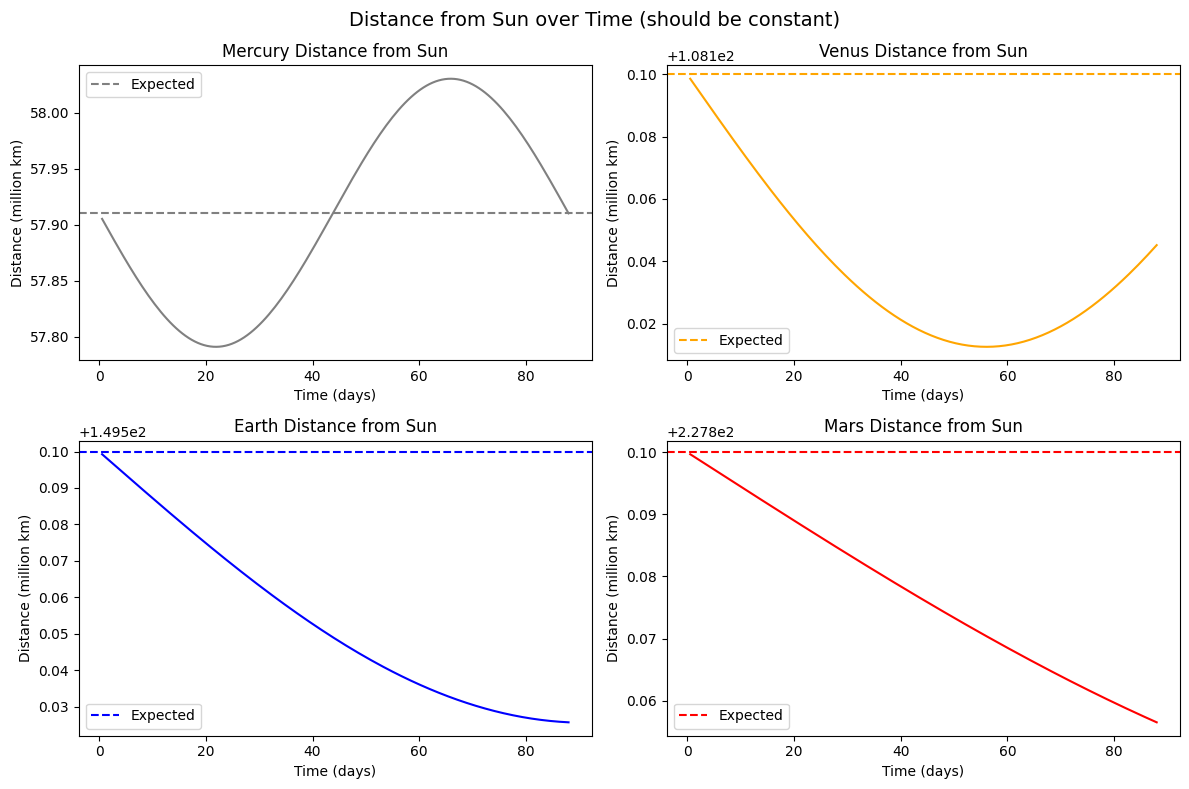

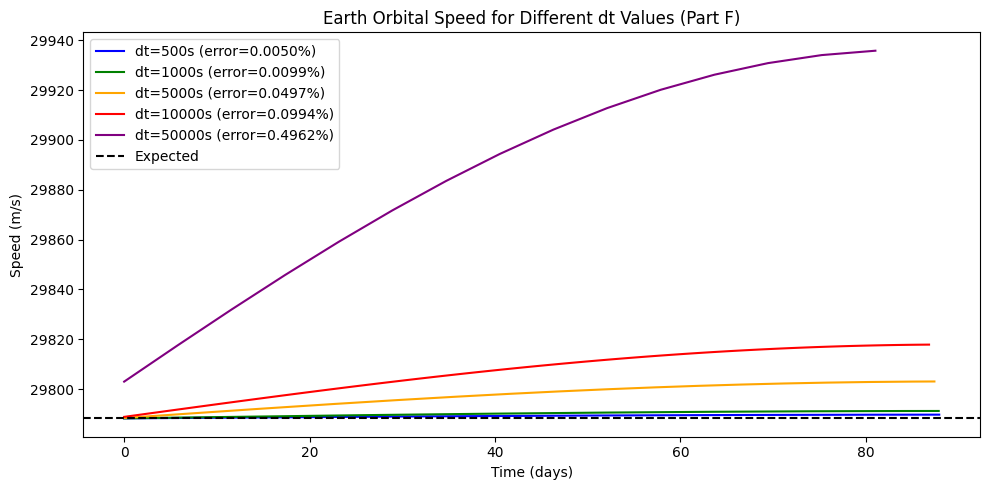


Part F - dt accuracy comparison for Earth:
  dt=   500s  |  error=0.0050%
  dt=  1000s  |  error=0.0099%
  dt=  5000s  |  error=0.0497%
  dt= 10000s  |  error=0.0994%
  dt= 50000s  |  error=0.4962%


In [1]:
from vpython import *
import math
import matplotlib.pyplot as plt

scene = canvas()
scene.autoscale = False

# Sun
rS = 6.957e8
Sun = sphere(pos=vec(0, 0, 0), radius=rS*10, color=color.yellow)

# Planet radii (m)
rMe = 2.439e6
rV  = 6.052e6
rE  = 6.371e6
rMa = 3.390e6

# Real orbital distances from Sun (m)
# Source: NASA Solar System Exploration https://solarsystem.nasa.gov
dMe = 5.791e10
dV  = 1.082e11
dE  = 1.496e11
dMa = 2.279e11

scene.range = 1.5 * dMa

Mercury = sphere(pos=vec(dMe, 0, 0), radius=rMe*500, color=color.white, make_trail=True)
Venus   = sphere(pos=vec(dV,  0, 0), radius=rV*500,  color=color.orange, make_trail=True)
Earth   = sphere(pos=vec(dE,  0, 0), radius=rE*500,  color=color.blue, make_trail=True)
Mars    = sphere(pos=vec(dMa, 0, 0), radius=rMa*500, color=color.red, make_trail=True)

G  = 6.674e-11
mS = 1.989e30

# Theoretical orbital velocities - Source: v = sqrt(G*M/r) (Newton's law of gravitation)
# Expected values from NASA: https://nssdc.gsfc.nasa.gov/planetary/factsheet/
vMe_expected = math.sqrt(G * mS / dMe)  # 47,872 m/s
vV_expected  = math.sqrt(G * mS / dV)   # 35,021 m/s
vE_expected  = math.sqrt(G * mS / dE)   # 29,783 m/s
vMa_expected = math.sqrt(G * mS / dMa)  # 24,131 m/s

print("=" * 55)
print("Expected orbital velocities (NASA / theoretical):")
print(f"  Mercury: {vMe_expected:.2f} m/s  (NASA: 47,872 m/s)")
print(f"  Venus:   {vV_expected:.2f} m/s  (NASA: 35,021 m/s)")
print(f"  Earth:   {vE_expected:.2f} m/s  (NASA: 29,783 m/s)")
print(f"  Mars:    {vMa_expected:.2f} m/s  (NASA: 24,131 m/s)")
print("=" * 55)

velocityMe = vec(0, vMe_expected, 0)
velocityV  = vec(0, vV_expected,  0)
velocityE  = vec(0, vE_expected,  0)
velocityMa = vec(0, vMa_expected, 0)

dt = 5000
t  = 0
mercury_year = 88 * 86400

# --- Data collection lists for plotting ---
times      = []
speeds_Me  = []
speeds_V   = []
speeds_E   = []
speeds_Ma  = []
dist_Me    = []
dist_V     = []
dist_E     = []
dist_Ma    = []

while t < mercury_year:
    rate(1000)

    # --- Mercury ---
    d_vec = Mercury.pos - Sun.pos
    d_mag = mag(d_vec)
    F = -(G * mS / d_mag**2) * (d_vec / d_mag)
    velocityMe += F * dt
    Mercury.pos += velocityMe * dt

    # --- Venus ---
    d_vec = Venus.pos - Sun.pos
    d_mag = mag(d_vec)
    F = -(G * mS / d_mag**2) * (d_vec / d_mag)
    velocityV += F * dt
    Venus.pos += velocityV * dt

    # --- Earth ---
    d_vec = Earth.pos - Sun.pos
    d_mag = mag(d_vec)
    F = -(G * mS / d_mag**2) * (d_vec / d_mag)
    velocityE += F * dt
    Earth.pos += velocityE * dt

    # --- Mars ---
    d_vec = Mars.pos - Sun.pos
    d_mag = mag(d_vec)
    F = -(G * mS / d_mag**2) * (d_vec / d_mag)
    velocityMa += F * dt
    Mars.pos += velocityMa * dt

    t += dt

    # collect every 10 steps to keep lists manageable
    if int(t / dt) % 10 == 0:
        days = t / 86400
        times.append(days)
        speeds_Me.append(mag(velocityMe))
        speeds_V.append(mag(velocityV))
        speeds_E.append(mag(velocityE))
        speeds_Ma.append(mag(velocityMa))
        dist_Me.append(mag(Mercury.pos - Sun.pos) / 1e9)  # convert to 1000 km
        dist_V.append(mag(Venus.pos   - Sun.pos) / 1e9)
        dist_E.append(mag(Earth.pos   - Sun.pos) / 1e9)
        dist_Ma.append(mag(Mars.pos   - Sun.pos) / 1e9)

print(f"\nSimulation complete: 1 Mercury year (88 days)")
print("\nFinal simulated vs expected velocities:")
print(f"  Mercury: {mag(velocityMe):.2f} vs {vMe_expected:.2f} m/s  | error: {abs(mag(velocityMe)-vMe_expected)/vMe_expected*100:.4f}%")
print(f"  Venus:   {mag(velocityV):.2f} vs {vV_expected:.2f} m/s  | error: {abs(mag(velocityV)-vV_expected)/vV_expected*100:.4f}%")
print(f"  Earth:   {mag(velocityE):.2f} vs {vE_expected:.2f} m/s  | error: {abs(mag(velocityE)-vE_expected)/vE_expected*100:.4f}%")
print(f"  Mars:    {mag(velocityMa):.2f} vs {vMa_expected:.2f} m/s  | error: {abs(mag(velocityMa)-vMa_expected)/vMa_expected*100:.4f}%")

# ============================================================
# PART E
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Solar System Simulation Verification (dt=5000s)", fontsize=14)

# Speed over time for each planet with expected value as dashed line
ax = axes[0, 0]
ax.plot(times, speeds_Me, color='gray',   label='Mercury simulated')
ax.axhline(vMe_expected, color='gray',   linestyle='--', label='Mercury expected')
ax.set_title("Mercury Orbital Speed")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Speed (m/s)")
ax.legend()

ax = axes[0, 1]
ax.plot(times, speeds_V, color='orange', label='Venus simulated')
ax.axhline(vV_expected,  color='orange', linestyle='--', label='Venus expected')
ax.set_title("Venus Orbital Speed")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Speed (m/s)")
ax.legend()

ax = axes[1, 0]
ax.plot(times, speeds_E, color='blue',   label='Earth simulated')
ax.axhline(vE_expected,  color='blue',   linestyle='--', label='Earth expected')
ax.set_title("Earth Orbital Speed")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Speed (m/s)")
ax.legend()

ax = axes[1, 1]
ax.plot(times, speeds_Ma, color='red',   label='Mars simulated')
ax.axhline(vMa_expected, color='red',    linestyle='--', label='Mars expected')
ax.set_title("Mars Orbital Speed")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Speed (m/s)")
ax.legend()

plt.tight_layout()
plt.savefig("verification_speeds.png")
plt.show()

# Distance from Sun over time (should be nearly constant for circular orbit)
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))
fig2.suptitle("Distance from Sun over Time (should be constant)", fontsize=14)

for ax, dist, name, color_, expected in zip(
    axes2.flat,
    [dist_Me, dist_V, dist_E, dist_Ma],
    ['Mercury', 'Venus', 'Earth', 'Mars'],
    ['gray', 'orange', 'blue', 'red'],
    [dMe/1e9, dV/1e9, dE/1e9, dMa/1e9]
):
    ax.plot(times, dist, color=color_)
    ax.axhline(expected, color=color_, linestyle='--', label='Expected')
    ax.set_title(f"{name} Distance from Sun")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Distance (million km)")
    ax.legend()

plt.tight_layout()
plt.savefig("verification_distances.png")
plt.show()

# ============================================================
# PART F 
# ============================================================
def run_sim(dt_val):
    """Run simulation with given dt, return final speed error for Earth"""
    pos  = vec(dE, 0, 0)
    vel  = vec(0, vE_expected, 0)
    t    = 0
    speeds = []
    while t < mercury_year:
        d_vec = pos - vec(0, 0, 0)
        d_mag = mag(d_vec)
        F = -(G * mS / d_mag**2) * (d_vec / d_mag)
        vel += F * dt_val
        pos += vel * dt_val
        t   += dt_val
        if int(t / dt_val) % 10 == 0:
            speeds.append(mag(vel))
    error = abs(mag(vel) - vE_expected) / vE_expected * 100
    return speeds, error

dt_values = [500, 1000, 5000, 10000, 50000]
colors     = ['blue', 'green', 'orange', 'red', 'purple']
errors     = []

fig3, ax3 = plt.subplots(figsize=(10, 5))
for dt_val, col in zip(dt_values, colors):
    spds, err = run_sim(dt_val)
    t_axis = [i * 10 * dt_val / 86400 for i in range(len(spds))]
    ax3.plot(t_axis, spds, color=col, label=f"dt={dt_val}s (error={err:.4f}%)")
    errors.append(err)

ax3.axhline(vE_expected, color='black', linestyle='--', label='Expected')
ax3.set_title("Earth Orbital Speed for Different dt Values (Part F)")
ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Speed (m/s)")
ax3.legend()
plt.tight_layout()
plt.savefig("dt_comparison.png")
plt.show()

print("\nPart F - dt accuracy comparison for Earth:")
for dt_val, err in zip(dt_values, errors):
    print(f"  dt={dt_val:6d}s  |  error={err:.4f}%")

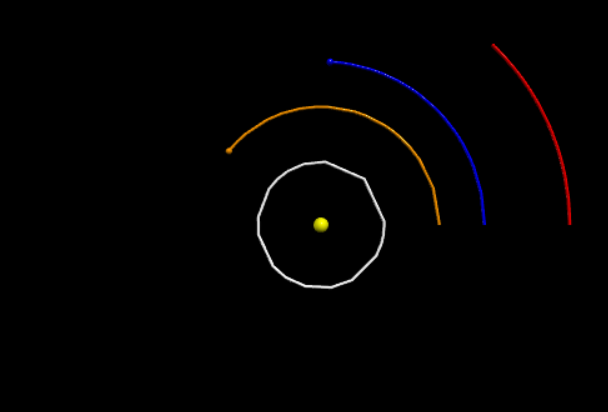
Screenshot of solar system after 1 mercury year (88 days)

C. All constants for each planet can be found on the NASA website for object parameters. For initial velocity however I used the equation for Theoretical orbital velocity: v = sqrt(G*mS/d). I used this to get the Velocities of each planet. Fo simulation time, I tried to choose a dt where it was fast enough to percieve the orbits, but not too fast that the animation would glitch out. 

D. I made he solar system very similarly on how to make the newton cannon ball. The difference being that instead of a cannon it is 4 seperate planets orbiting around the sun. I didnot use any functions like I should, I only used while loops and put each individual plantes physics changes inside it.

E. I measured distance from sun and velocities of each planet. I did this because they are typically dynamic values when measuring orbits. From this I can tell that Venus has the most error, by a little but more than the other values.  Cite: https://www.nasa.gov/nssdc/

F.Using Eath comparisons The higher the DT the less accurate, in the simulation a higher dt the trail jumps around the sun and gets very glitchy. When it is a slow dt the planets take a while to move around but more accurate

